# **Proyecto 05: Sistema de Identificación del Género de una Canción**

---

## **Parte 1: Carga de los datos**

En este proyecto, vamos a construir una red neuronal artificial que puede identificar el género de una canción, utilizando la librería GTZAN Genre Collection. Para extraer los features (características) de las canciones, vamos a utilizar la librería de Python [**librosa**](https://librosa.org/). Utilizaremos los Mel-frequency cepstral coefficients (MFCC), que simulan la escucha humana y son coúnmente utilizados en aplicaciones de speech recognition (reconocimiento del habla) así como en detección del género musical. Estos valores serán los que utilizaremos como entrada de la red neuronal.

KeyError: 'zcr_mean'

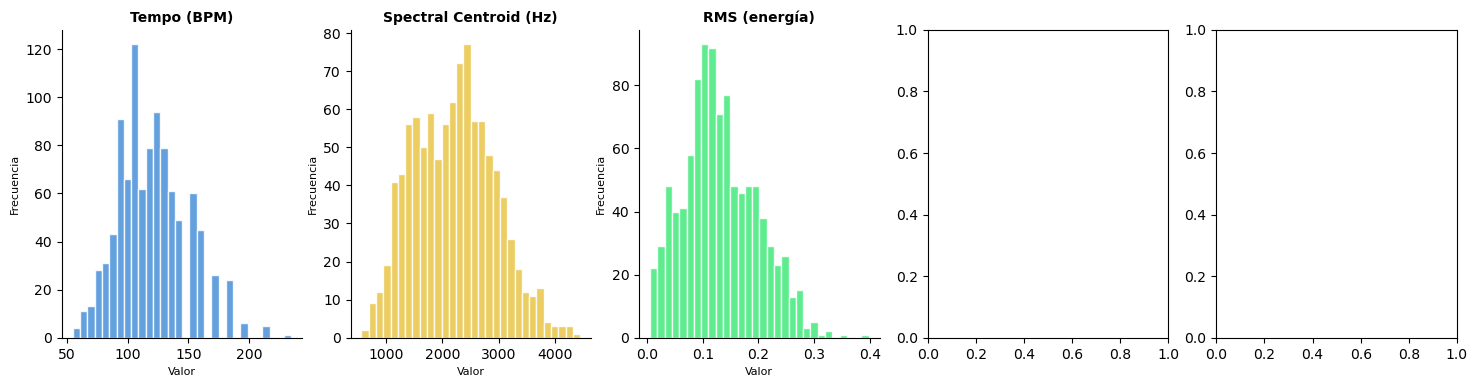

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('features_30_sec.csv')

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.patch.set_facecolor('white')

variables = ['tempo', 'spectral_centroid_mean', 'rms_mean', 'zcr_mean', 'mfcc1_mean']
nombres   = ['Tempo (BPM)', 'Spectral Centroid (Hz)', 'RMS (energía)', 'ZCR', 'MFCC1']
colores   = ['#4a90d9', '#e8c547', '#43e97b', '#ff6584', '#6c63ff']

for ax, var, nombre, color in zip(axes, variables, nombres, colores):
    ax.hist(df[var], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(nombre, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribuciones de las principales variables — features_30_sec.csv',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figura1_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
print(df.columns.tolist())

['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']


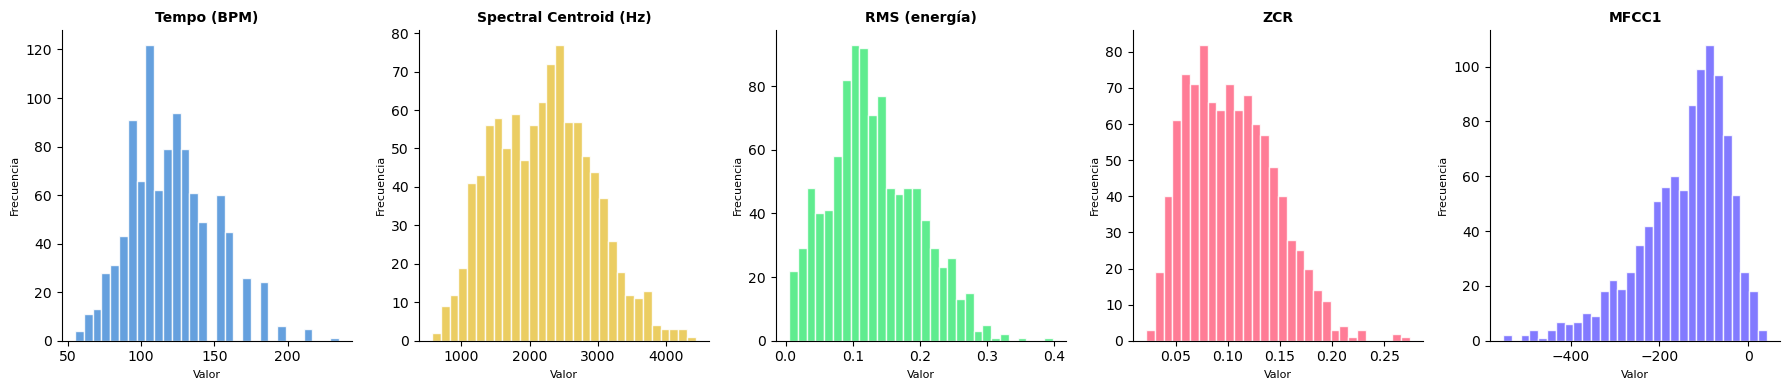

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

variables = ['tempo', 'spectral_centroid_mean', 'rms_mean', 'zero_crossing_rate_mean', 'mfcc1_mean']
nombres   = ['Tempo (BPM)', 'Spectral Centroid (Hz)', 'RMS (energía)', 'ZCR', 'MFCC1']
colores   = ['#4a90d9', '#e8c547', '#43e97b', '#ff6584', '#6c63ff']

for ax, var, nombre, color in zip(axes, variables, nombres, colores):
    ax.hist(df[var], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(nombre, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figura1_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'], check=True)

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

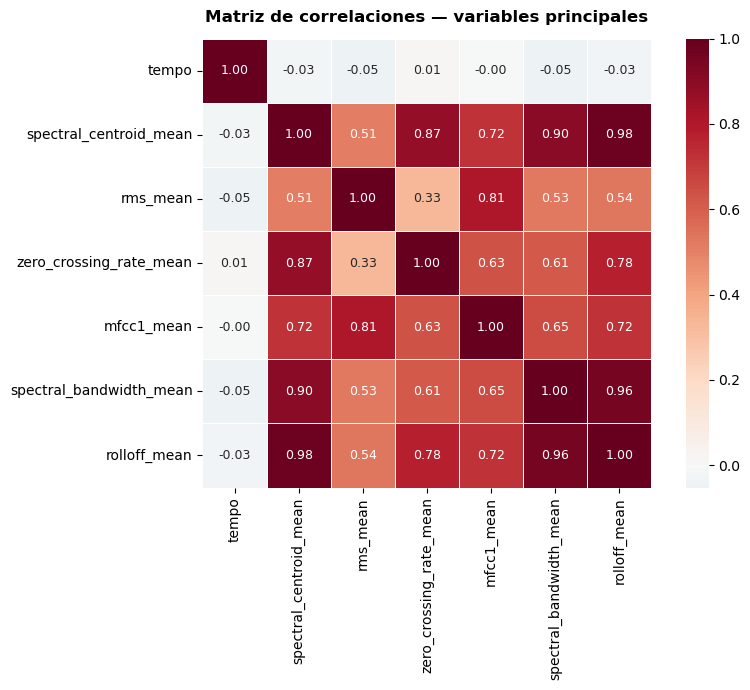

In [7]:
import seaborn as sns

variables_corr = ['tempo', 'spectral_centroid_mean', 'rms_mean', 
                  'zero_crossing_rate_mean', 'mfcc1_mean', 
                  'spectral_bandwidth_mean', 'rolloff_mean']

corr = df[variables_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Matriz de correlaciones — variables principales', 
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figura2_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import glob
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

def display_mfcc(song):
    y, sr = librosa.load(song)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.colorbar()
    plt.title(f'MFCC - {song}')
    plt.tight_layout()
    plt.show()

<class 'ModuleNotFoundError'>: No module named 'librosa'

Para entender qué son los MFCC, podemos descargar Kick Loop 5 by Stereo Surgeon desde [https://freesound.org/people/Stereo%20Surgeon/sounds/266093](https://freesound.org/people/Stereo%20Surgeon/sounds/266093), y también descargar Whistling by cmagar desde [https://freesound.org/people/grrlrighter/sounds/98195/](https://freesound.org/people/grrlrighter/sounds/98195/). Uno de ellos es un beat de bajas frecuencias, mientras que el otros es un silbido de frecuencias más agudas. Veremos mediante los valores MFCC como estos dos sonidos son claramente distintos.

Además de importar la librería librosa, también vamos a usar [**glob**](https://docs.python.org/es/3/library/glob.html) para poder hacer un listado de los archivos en los diferentes repositorios de los géneros musicales. Además, utilizaremos <span style="color:blue"> **numpy**</span> y <span style="color:blue"> **matplotlib**</span>.

También vamos a importar el modelo **Sequential** de **Keras**. Este es un modelo típico de red neuronal feed-forward. Finalmente, importaremos una capa densa de una red neuronal (capa con una colección de neuronas en ella, [**Dense**](https://keras.io/api/layers/core_layers/dense/https://keras.io/api/layers/core_layers/dense/)).


A diferencia de con las operaciones convolución, por ejemplo, esta red va a tener representaciones en dos dimensiones. Vamos a importar funciones de activación, lo que nos permitirá decidir en cada capa de la red neuronal que función no lineal utilizar, y también importaremos la función <span style="color:blue"> **to_categorical**</span>, que nos permite cambiar los nombres de las clases en categorías, que es lo que ocurre con el one-hot encoding. 

En primer lugar, vamos a definir una función llamada <span style="color:blue"> **display_mfcc**</span> que nos permitirá visualizar en un gráfico estos valores. Los MFCC se pueden obtener a partir de la librería librosa. Para visualizar, utilizaremos un tipo de gráfico conocido como espectrograma, que pertenece a la libraría librosa (<span style="color:blue"> **specshow**</span>).

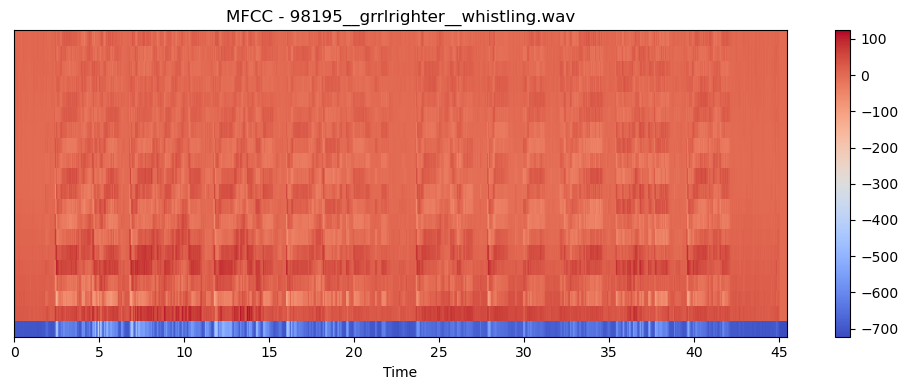

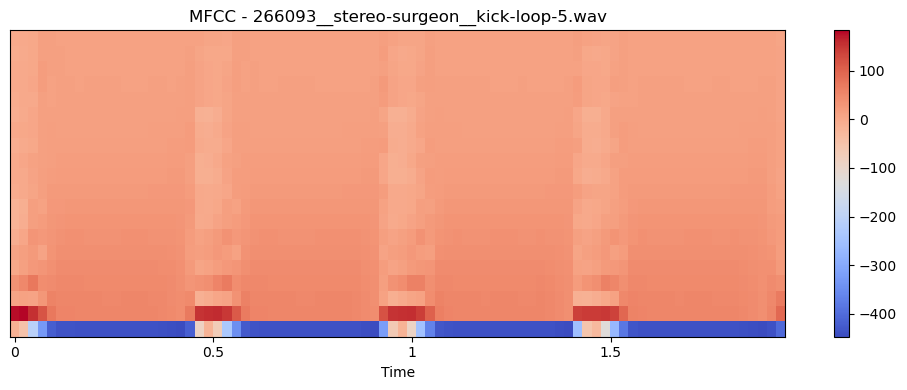

In [21]:
display_mfcc('98195__grrlrighter__whistling.wav')
display_mfcc('266093__stereo-surgeon__kick-loop-5.wav')

Vamos a probar esta función que hemos creado con las canciones 'kick-loop.wav' y 'whistling.wav' que hemos importado previamente. 

---
## **Parte 2: Preprocesado de los datos**

Ahora que ya podemos visualizar los coeficientes MCFF, vamos a crear otra función auxiliar, que nos permitirá obtener dichos coeficientes y guardarlos en un vector. Para mejor funcionamiento de la posterior red neuronal, vamos a normalizar los coeficients para que su rango esté comprendido entre -1 y 1, y solamente vamos a utilizar los primeros 25000 coeficientes. A la función auxiliar la vamos a llamar  <span style="color:blue"> **extract_features_song**</span> 

In [22]:
def extract_features_song(path):
    y, sr = librosa.load(path)
    mfcc = librosa.feature.mfcc(y=y, sr=sr)
    
    # Aplanar los coeficientes en un vector
    mfcc = mfcc.flatten()
    
    # Quedarnos solo con los primeros 25000 coeficientes
    mfcc = mfcc[:25000]
    
    # Normalizar al rango [-1, 1]
    mfcc = mfcc / np.max(np.abs(mfcc))
    
    return mfcc

A continuación vamos a definir una rutina para abrir los ficheros con las canciones de los distintos géneros y extraer los coeficientes MCFF de ellas. La función se llamará  <span style="color:blue"> **generate_features_and_labels**</span>, y en ella haremos un bucle sobre todos los géneros, y buscaremos en la carpeta de cada género todos los archivos, los abriremos y extraeremos los MCFF mediante la función extract_features_song. Al mismo tiempo, crearemos un vector de etiquetas (labels) y añadiremos el género a ese vector cada vez que abramos un fichero. Sin embargo, la red neuronal no es capaz de predecir una palabra o letras. Para poder utilizarla, necesitamos hacer un one-hot encoding, lo que significa que cada palabra será representada por un vector de diez números binarios (tenemos 10 clases en total), de manera que solamente uno de los números sea 1 y el resto sean 0. Utilizaremos la función  <span style="color:blue"> **np.unique**</span> para hacer que las etiquetas se conviertan en números enteros. Luego, utilizamos la función  <span style="color:blue"> **to_categorical**</span>, que convertirá esos números enteros en representación one-hot encoding. Por último, utilizamos la función  <span style="color:blue"> **np.stack**</span> sobre los features que hemos extraído de las canciones para que se junten en una única matriz.    

In [23]:
def generate_features_and_labels():
    all_features = []
    all_labels = []
    
    genres = glob.glob('genres_original/*')
    
    for genre in genres:
        genre_name = genre.split('\\')[-1]  # En Windows usa '\\'
        songs = glob.glob(f'{genre}/*.wav')
        
        for song in songs:
            try:
                features = extract_features_song(song)
                if len(features) == 25000:
                    all_features.append(features)
                    all_labels.append(genre_name)
            except Exception as e:
                print(f'Error con {song}: {e}')
    
    # Convertir etiquetas a números enteros
    _, labels_encoded = np.unique(all_labels, return_inverse=True)
    
    # One-hot encoding
    labels_onehot = to_categorical(labels_encoded)
    
    # Juntar features en una matriz
    features_matrix = np.stack(all_features)
    
    return features_matrix, labels_onehot

print("Extrayendo características... (esto puede tardar varios minutos)")
X, y = generate_features_and_labels()
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extrayendo características... (esto puede tardar varios minutos)


C:\Users\hruiz\AppData\Local\Temp\ipykernel_13776\2700136845.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
,  y, sr = librosa.load(path)


Error con genres_original\jazz\jazz.00054.wav: 
,Features shape: (999, 25000)
,Labels shape: (999, 10)


Vamos a dividir el dataset de features y labels en train y test, dejando un 80% de los datos para el train y un 20% para el test. Antes de dividir, hay que primero juntar los datos de los features y las etiquetas utilizando la función  <span style="color:blue"> **np.column_stack**</span>, luego  hay que barajar los datos para no producir artefactos debido al orden de los datos en el modelo, para ello, podemos utilizar la función  <span style="color:blue"> **shuffle**</span>. Una vez separados en train y test, debemos eliminar de cada set las 10 últimas columnas, puesto que son las columnas correspondientes al one-hot encoding, que no necesitamos como entrada, si no como salida de nuestra red neuronal.

In [24]:

data = np.column_stack([X, y])

# Barajar los datos
data = shuffle(data, random_state=42)

# Calcular el punto de corte 80/20
split = int(0.8 * len(data))

# Dividir en train y test
train = data[:split]
test = data[split:]

# Separar features (X) y labels (y)
# Las últimas 10 columnas son el one-hot encoding
X_train = train[:, :-10]
y_train = train[:, -10:]
X_test = test[:, :-10]
y_test = test[:, -10:]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (799, 25000)
,y_train: (799, 10)
,X_test: (200, 25000)
,y_test: (200, 10)


---
## **Parte 3: Análisis del modelo (entrenamiento de la red neuronal)**

Seguidamente construimos la red neuronal. Vamos a utilizar un modelo secuencial ( <span style="color:blue"> **Sequential**</span>). Añadiremos una capa densa de 100 neuronas en primer lugar, definiendo también en esta primera capa el tamaño de entrada de la red (que podemos obtener a partir del tamaño del train dataset). La función de activación que escogeremos para la primera capa es la función  <span style="color:red"> 'relu'</span>, y luego añadimos una segunda capa densa de 10 neuronas con una función de activación de tipo  <span style="color:red"> 'softmax'</span>. El tamaño de la segunda capa viene fijado por el número de clases que tenemos en nuestro clasificador, es decir 10 géneros musicales distintos. La activación  <span style="color:red"> 'softmax'</span> coge las 10 salidas y las normaliza de tal forma que la suma de las 10 sea 1. De esta forma, acaban representando probabilidades, así que la predicción será aquella que tenga una probabilidad mayor. 

Una vez creado el modelo, debemos compilarlo (instrucción [**compile**](https://www.tensorflow.org/api_docs/python/tf/keras/Model)), añadiendo algunos hiperparámetros de como funciona nuestro algoritmo. En concreto, vamos a utilizar el optimizador  <span style="color:red"> 'adam'</span>, y la función de pérdidas será  <span style="color:red"> 'categorical_crossentropy'</span>. Por último, la medida que queremos ver durante la evaluación es la medida de  <span style="color:red"> 'accuracy'</span>. Par apoder ver un resumen de la arquitectura creada, podemos mostrar por pantalla un resumen <span style="color:blue"> **model.summary**</span> que nos da los detalles sobre las capas.

In [25]:
model = Sequential([
    Dense(100, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 100)                 │       2,500,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,501,110 (9.54 MB)

 Trainable params: 2,501,110 (9.54 MB)

 Non-trainable params: 0 (0.00 B)

Por último, solamente tenemos que entrenar el model [**fit**](https://www.tensorflow.org/api_docs/python/tf/keras/Model) definiendo como entradas los datos de entrenamiento (tanto los features como las etiquetas, y definimos el número de épocas (10 por ejemplo), el tamaño del batch (32 por ejemplo) y el tamaño del conjunto de validación (0.2 por ejemplo). Por último, obtendremos las métricas de nuestro sistema evaluando la precisión mediante los datos de test con la función [**evaluate**](https://www.tensorflow.org/api_docs/python/tf/keras/Model).

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2160 - loss: 2.5195 - val_accuracy: 0.4000 - val_loss: 1.8525
,Epoch 2/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3756 - loss: 1.7312 - val_accuracy: 0.3250 - val_loss: 1.6841
,Epoch 3/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4351 - loss: 1.4853 - val_accuracy: 0.3750 - val_loss: 1.6727
,Epoch 4/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5509 - loss: 1.3212 - val_accuracy: 0.4437 - val_loss: 1.5985
,Epoch 5/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6854 - loss: 1.0792 - val_accuracy: 0.5312 - val_loss: 1.4587
,Epoch 6/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7449 - loss: 0.9338 - val_accuracy: 0.4875 - val_loss: 1.5441
,Epoch 7/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8247 - loss: 0.7738 - val_accuracy: 0.5312 - val_loss: 1.4446
,Epoch 8/10
,20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8717 - loss: 0.6698 - val_accur

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5750 - loss: 1.4071  
,
,Precisión en test: 57.50%
,Pérdida en test: 1.4071


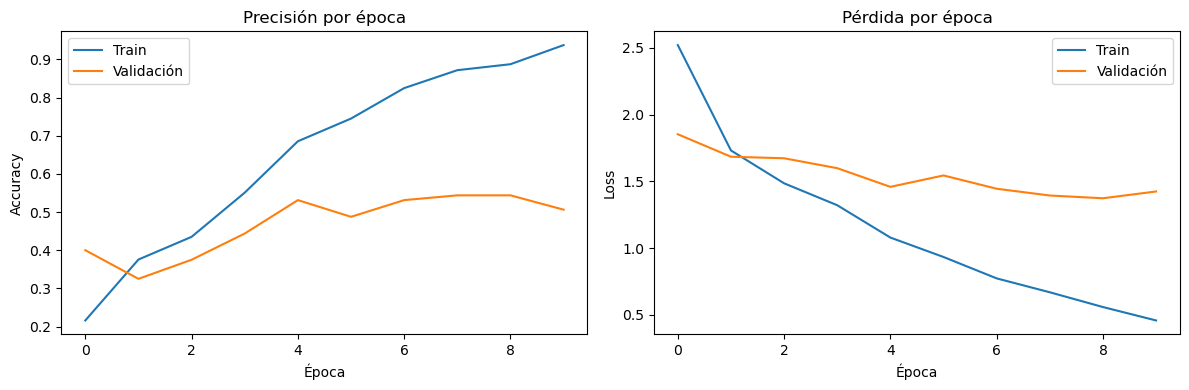

In [27]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nPrecisión en test: {accuracy * 100:.2f}%")
print(f"Pérdida en test: {loss:.4f}")

# Gráfica del entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
model.save('modelo_generos.h5')
print("Modelo guardado correctamente")

Modelo guardado correctamente
